In [1]:
import subprocess

In [1]:
# Set bounds
MIN = 0
MAX = 250

In [3]:
# Capture
# DONE

"""
import os
from tqdm import tqdm

for i in tqdm(range(MIN+1, MAX+1)):
    random_data = os.urandom(125000) # 10^6 bits
    strings = []

    for byte in random_data:
        str_rep = f"{byte:08b}"
        strings.append(str_rep)
        
    with open(f"./data/urandom/{i:03d}", "w") as f:
        for i in range(len(strings)):
            if i % 4 == 0 and i != 0: # ensure newline consistency with pinecone captures
                f.write("\n")
            f.write(strings[i])
"""

'\nimport os\nfrom tqdm import tqdm\n\nfor i in tqdm(range(MIN+1, MAX+1)):\n    random_data = os.urandom(125000) # 10^6 bits\n    strings = []\n\n    for byte in random_data:\n        str_rep = f"{byte:08b}"\n        strings.append(str_rep)\n\n    with open(f"./data/urandom/{i:03d}", "w") as f:\n        for i in range(len(strings)):\n            if i % 4 == 0 and i != 0: # ensure newline consistency with pinecone captures\n                f.write("\n")\n            f.write(strings[i])\n'

In [4]:
# Evaluate
# DONE
#import subprocess

#for i in range(MIN+1, MAX+1):
#    subprocess.run(["cargo", "run", "evaluate", f"--path=data/urandom/{i:03d}", f"--out-path=data/urandom/{i:03d}-results.json"])

In [2]:
# Evaluate files
import json

contents = []

for i in range(1, MAX+1):
    file = f"data/urandom/{i:03d}-results.json"

    with open(file, "r") as f:
        content = json.load(f)
        
    contents.append(content)

In [3]:
# Combine results
results = dict()

# Create keys
for key in ["monobit_frequency", "block_frequency", "runs", "longest_run",
            "binary_rank", "dft", "non_overlapping", "overlapping", "universal",
            "linear_complexity", "serial", "approximate_entropy", "cusum",
            "random_excursions", "random_excursions_variant", #"universal_cn", "universal_t", "universal_t_cn"
            ]:
    results[key] = []

In [4]:
for content in contents:
    for key, value in content.items():
        match key:
            case "monobit_frequency" | "block_frequency" \
                | "runs" | "longest_run" | \
                "binary_rank" | "dft" \
                | "linear_complexity" | "approximate_entropy":
                results[key].append(value)
            case "non_overlapping" | "serial" | "cusum" \
                | "overlapping" | "random_excursions" | "random_excursions_variant":
                results[key].extend(value)
            case "universal":
                results[key].append(value[0])
                #results["universal_cn"].append(value[1])
                #results["universal_t"].append(value[2])
                #results["universal_t_cn"].append(value[3])

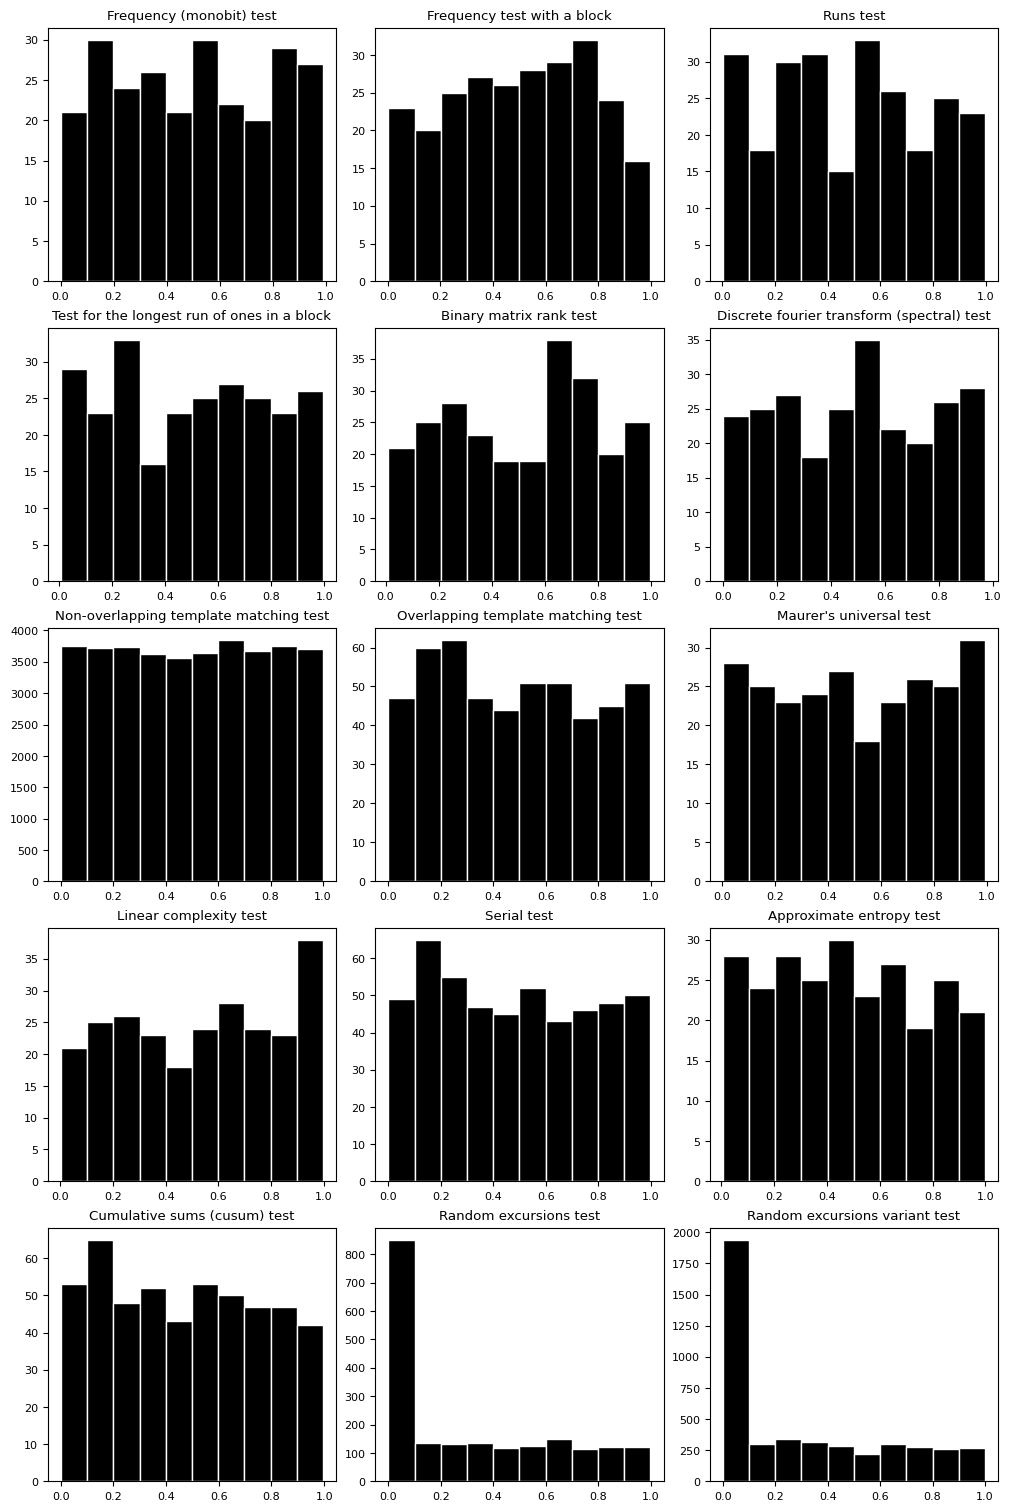

In [5]:
import matplotlib.pyplot as plt

descriptions = {
    "monobit_frequency": "Frequency (monobit) test",
    "block_frequency": "Frequency test with a block",
    "runs": "Runs test",
    "longest_run": "Test for the longest run of ones in a block",
    "binary_rank": "Binary matrix rank test",
    "dft": "Discrete fourier transform (spectral) test",
    "non_overlapping": "Non-overlapping template matching test",
    "overlapping": "Overlapping template matching test",
    "universal": "Maurer's universal test",
    "universal_cn": "Maurer's universal test (CN approx.)",
    "universal_t": "Maurer's universal test (t-test)",
    "universal_t_cn": "Maurer's universal test (CN approx.; t-test)",
    "linear_complexity": "Linear complexity test",
    "serial": "Serial test",
    "approximate_entropy": "Approximate entropy test",
    "cusum": "Cumulative sums (cusum) test",
    "random_excursions": "Random excursions test",
    "random_excursions_variant": "Random excursions variant test"
}
"""
for key in results.keys():
    fig, ax = plt.subplots()
    ax.hist(results[key], bins=10, edgecolor="white")
    ax.set_title(descriptions[key])
    plt.savefig(f"./figures/urandom/{key}.pdf")
"""

font = {"size": 8}
plt.rc("font", **font)

fig, axs = plt.subplots(5, 3, figsize=(10, 15), constrained_layout=True) # 3
i = 0
for key in results.keys():
    row = i % 3
    column = int(i/3)
    axs[column, row].hist(results[key], bins=10, edgecolor="white", color="black")
    axs[column, row].set_title(descriptions[key])
    i += 1
    
plt.savefig(f"./figures/urandom.pdf")

In [9]:
# Compute proportions
# MAX = sample size
alpha = 0.01
p = 1- alpha
confidence_min = p - 3 * (((p*(1-p))/MAX) ** 0.5)
confidence_max = p + 3 * (((p*(1-p))/MAX) ** 0.5)
print(f"min. confidence: {confidence_min:.4f}, max. confidence: {confidence_max:.4f}")

min. confidence: 0.9711, max. confidence: 1.0089


In [10]:
import numpy as np

# Table header
print("""\\begin{table}[htb]
\t\\centering
\t\\caption{Proportion of sequences passing a test - /dev/urandom}
\t\\label{tab:urandom-proportions}
\t\\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
\t\t\\hline
\t\tTest    &   Accepted observations   &   Proportion &   Result\\\\
\t\t\\hline""")

for key, value in results.items():
    print(f"\t\t{descriptions[key]}", end=" & ")
    
    # Compute proportion
    observations = np.array(value)
    accepted_p_values = (observations >= alpha).sum()
    proportion = accepted_p_values / len(observations)
    print(f"{accepted_p_values}/{len(observations)}", end=" & ")
    print(f"{proportion:.4f}", end=" & ")
    
    if confidence_min <= proportion <= confidence_max:
        print("accepted", end="\\\\\n")
    else:
        print("\\textbf{rejected}", end="\\\\\n")
        
    print("\t\t\\hline")
    
# Table footer
print("""\t\\end{tabular}
\\end{table}""")

\begin{table}[htb]
	\centering
	\caption{Proportion of sequences passing a test - /dev/urandom}
	\label{tab:urandom-proportions}
	\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
		\hline
		Test    &   Accepted observations   &   Proportion &   Result\\
		\hline
		Frequency (monobit) test & 243/250 & 0.9720 & accepted\\
		\hline
		Frequency test with a block & 248/250 & 0.9920 & accepted\\
		\hline
		Runs test & 248/250 & 0.9920 & accepted\\
		\hline
		Test for the longest run of ones in a block & 248/250 & 0.9920 & accepted\\
		\hline
		Binary matrix rank test & 250/250 & 1.0000 & accepted\\
		\hline
		Discrete fourier transform (spectral) test & 245/250 & 0.9800 & accepted\\
		\hline
		Non-overlapping template matching test & 36603/37000 & 0.9893 & accepted\\
		\hline
		Overlapping template matching test & 497/500 & 0.9940 & accepted\\
		\hline
		Maurer's universal test & 246/250 & 0.9840 & accepted\\
		\hline
		Linear complexity test & 248/250 & 0.9920 & accepted\\
		\hline
		Serial test & 49

In [11]:
import scipy

# Table header
print("""\\begin{table}[htb]
\t\\centering
\t\\caption{Uniform distribution of p-values - /dev/urandom}
\t\\label{tab:urandom-uniform}
\t\\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
\t\t\\hline
\t\tTest    &   $\\chi^2$-value   &   p-value &   Result\\\\
\t\t\\hline""")

# Perform goodness-of-fit X^2-test
for key, value in results.items():
    print(f"\t\t{descriptions[key]}", end=" & ")
    
    chi2 = 0.0
    observations = np.array(value)
    expected = len(value) / 10
    
    for i in range(10):
        # Range of accepted items
        min_ = i / 10
        max_ = min_ + 0.1
        accepted_number_p_values = ((observations >= min_) & (observations < max_)).sum()
        chi2 += (accepted_number_p_values - expected) ** 2
    
    # Compute chi-square
    chi2 /= expected
    print(f"{chi2:.4f}", end=" & ")
    pvalue = scipy.special.gammaincc(4.5, chi2/2)
    print(f"{pvalue:.4f}", end=" & ")
    
    if pvalue >= 0.0001:
        print("accepted", end="\\\\\n")
    else:
        print("\\textbf{rejected}", end="\\\\\n")
    print("\t\t\\hline")
    
# Table footer
print("""\t\\end{tabular}
\\end{table}""")

\begin{table}[htb]
	\centering
	\caption{Uniform distribution of p-values - /dev/urandom}
	\label{tab:urandom-uniform}
	\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
		\hline
		Test    &   $\chi^2$-value   &   p-value &   Result\\
		\hline
		Frequency (monobit) test & 7.9200 & 0.5422 & accepted\\
		\hline
		Frequency test with a block & 8.4800 & 0.4866 & accepted\\
		\hline
		Runs test & 16.3200 & 0.0605 & accepted\\
		\hline
		Test for the longest run of ones in a block & 7.8400 & 0.5503 & accepted\\
		\hline
		Binary matrix rank test & 13.2000 & 0.1538 & accepted\\
		\hline
		Discrete fourier transform (spectral) test & 9.2000 & 0.4190 & accepted\\
		\hline
		Non-overlapping template matching test & 15.2719 & 0.0837 & accepted\\
		\hline
		Overlapping template matching test & 8.4400 & 0.4905 & accepted\\
		\hline
		Maurer's universal test & 3.2800 & 0.9522 & accepted\\
		\hline
		Linear complexity test & 8.5600 & 0.4788 & accepted\\
		\hline
		Serial test & 7.0000 & 0.6371 & accepted\\
		\h